# K Means Clustering

## California Housing Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Intuition and when to use K-Means

In [ ]:
# K-Means is an unsupervised algorithm that groups unlabeled data into k clusters by  k similarity.

# It represents each cluster by a centroid (mean point), and tries to minimize the sum 
# of squared distances between points and their cluster centroid (within-cluster sum of squares / inertia).

In [ ]:
# Use K-Means when:

# You have numerical features (or can encode/scale them)and want to discover natural groupings 
# such as customer segments, geographic zones, or product groups.

# Clusters are roughly “spherical” and similar in size, and you mainly care about Euclidean
# distance in feature space.

# Step 2: EDA and data preprocessing

## 1. Understand the data (EDA)

In [3]:
df=pd.read_csv('housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [10]:
## Visualization

In [12]:
num_cols=df.select_dtypes(include='number').columns
num_cols

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

<Axes: xlabel='total_rooms', ylabel='total_bedrooms'>

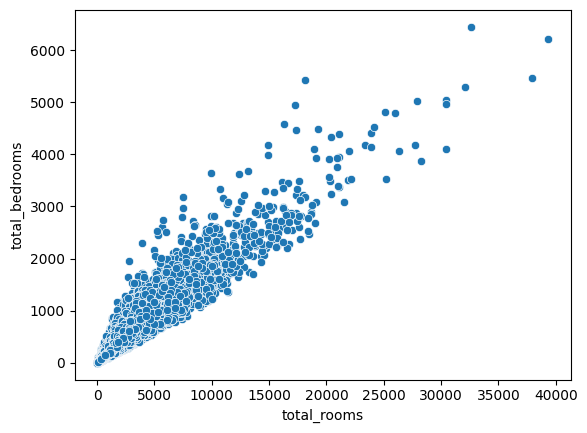

In [324]:
sns.scatterplot(data=df, x='total_rooms', y='total_bedrooms')

<Axes: xlabel='total_rooms', ylabel='total_bedrooms'>

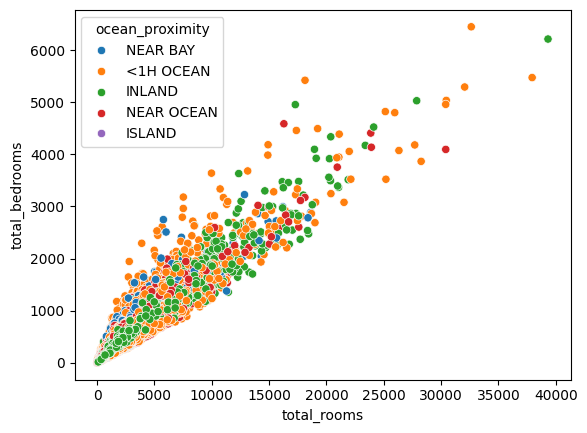

In [325]:
sns.scatterplot(data=df, x='total_rooms', y='total_bedrooms', hue='ocean_proximity')

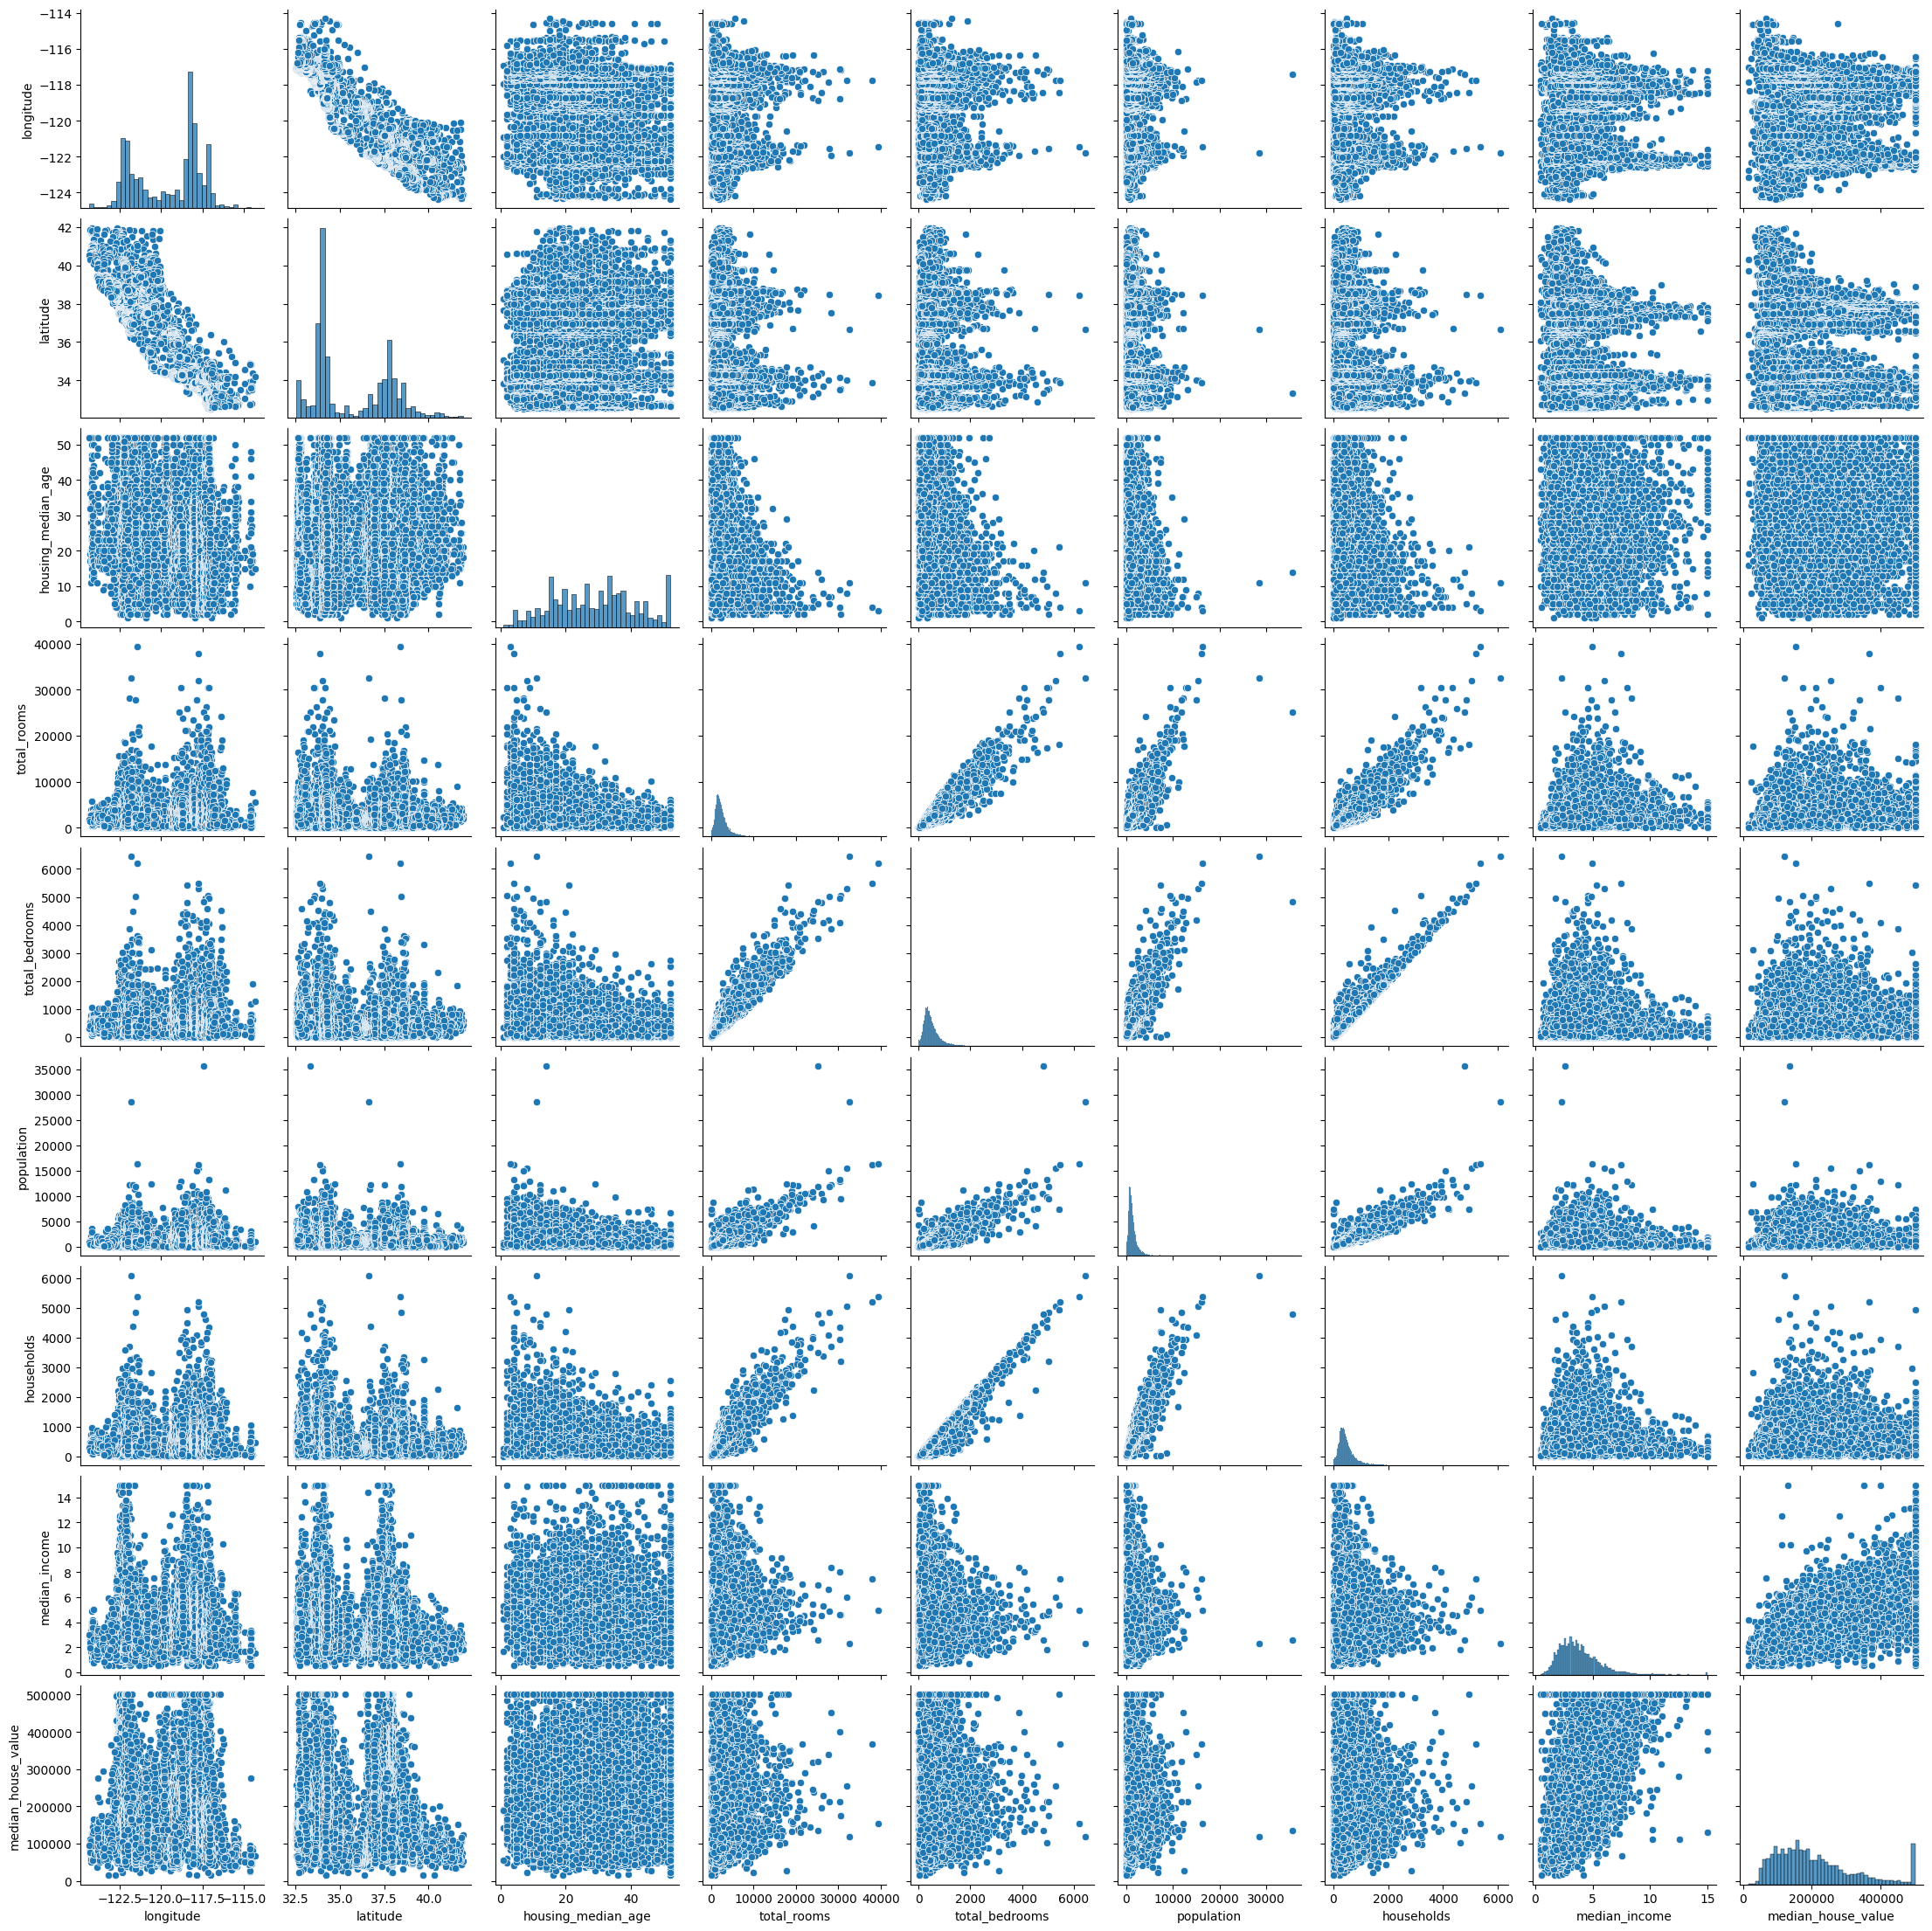

In [18]:
sns.pairplot(df[num_cols])

<Axes: >

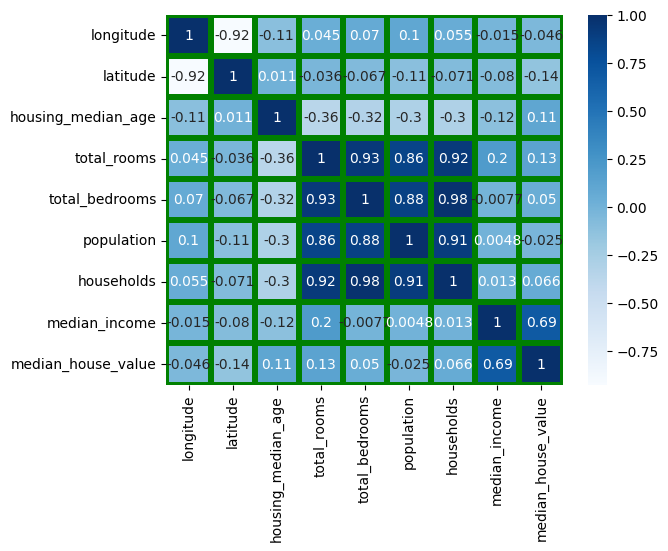

In [19]:
sns.heatmap( data=df[num_cols].corr(), annot=True, cmap='Blues', lw=3, linecolor='green')

In [20]:
## So as you can see features like
## ..............>>>>>>>>>>>>>>>>> total_rooms,  total_bedrooms, population, houshold are highly coreelated

In [21]:
best_features= ['total_rooms', 'total_bedrooms', 'population', 'households']

In [22]:
final_df=df[best_features]

In [23]:
final_df.head()

,total_rooms,total_bedrooms,population,households
0,880.0,129.0,322.0,126.0
1,7099.0,1106.0,2401.0,1138.0
2,1467.0,190.0,496.0,177.0
3,1274.0,235.0,558.0,219.0
4,1627.0,280.0,565.0,259.0


<Axes: >

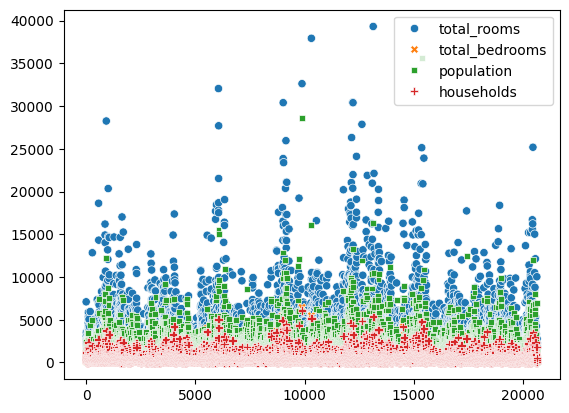

In [25]:
sns.scatterplot(final_df)

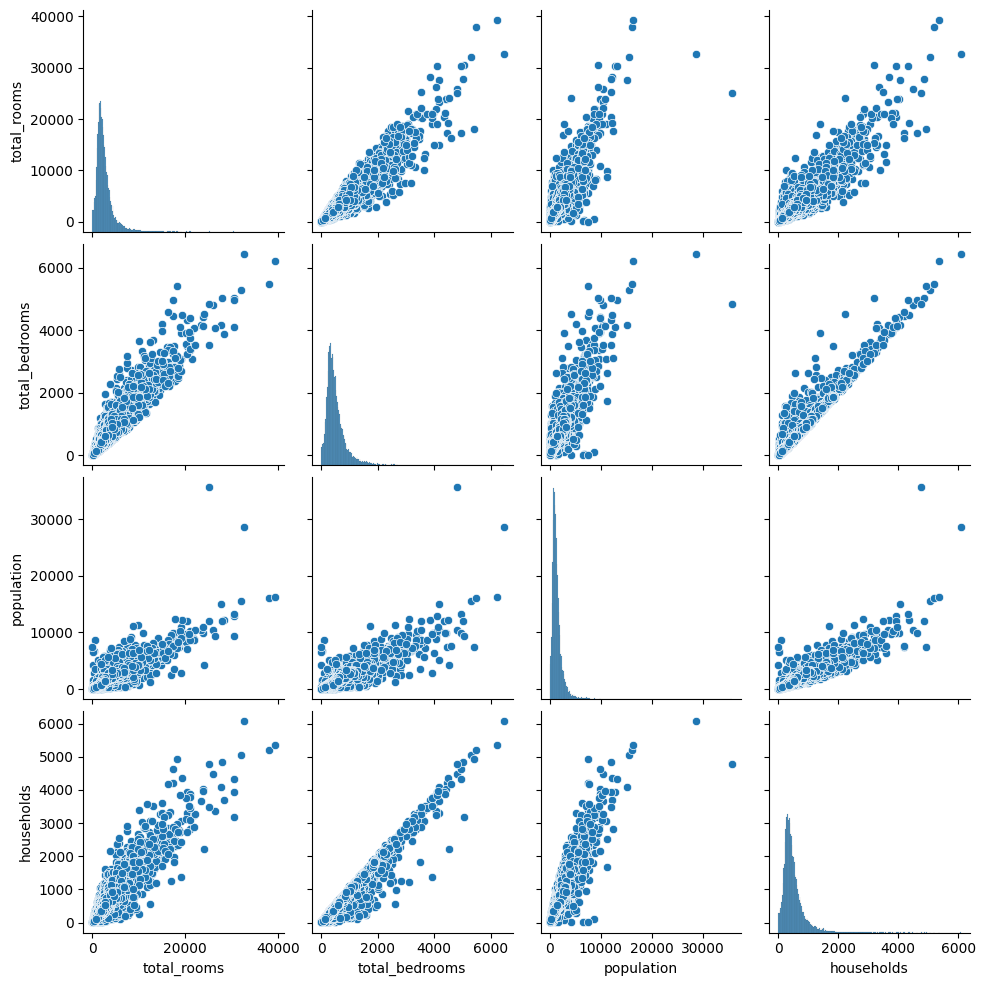

In [28]:
sns.pairplot(final_df , diag_kind='hist')

<Axes: >

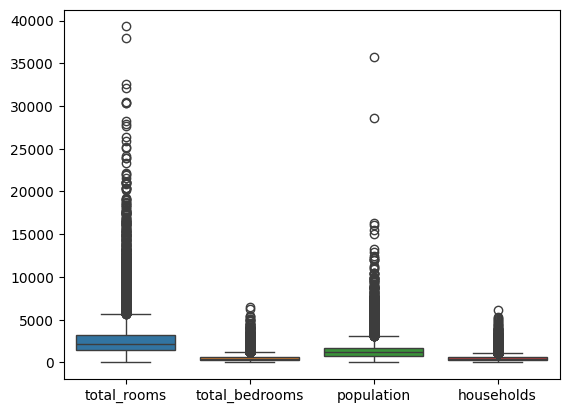

In [41]:
# plt.figure(figsize=(10,20))
sns.boxplot(data=final_df)

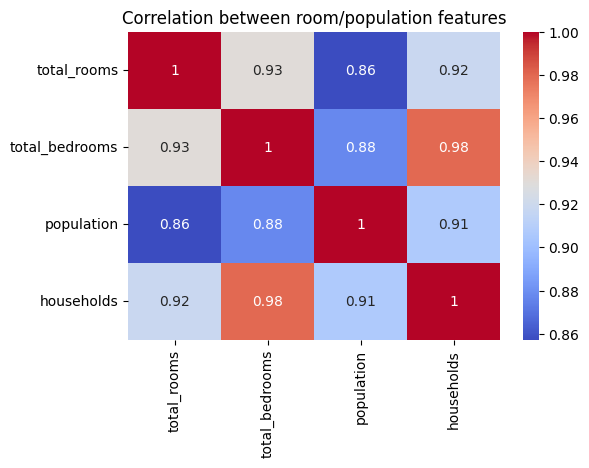

In [42]:
plt.figure(figsize=(6, 4))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between room/population features")
plt.show()

## 2. Handling Missing Values

In [ ]:
# In this dataset missing values are none..

# But you can handle them if they occure>>>>>>>>>>>>>>>>>>>>
        # Decide to drop rows/columns with too many missing values 
        # or impute (mean/median for continuous, mode for categorical)

## 3. Deal with categorical features

In [44]:
# K-Means is distance-based, so it works directly on numeric features

# My dataset contains only one categorical column..........ocean_proximity
# which i dropped due to low correlation

# One-hot encode a small number of categorical variables 
# (but remember high-dimensional one-hot can hurt)

# In this case my_final_df contains only numerical columns

In [ ]:
# AS my dataset containes thousands of ouliers

<Figure size 1000x400 with 0 Axes>

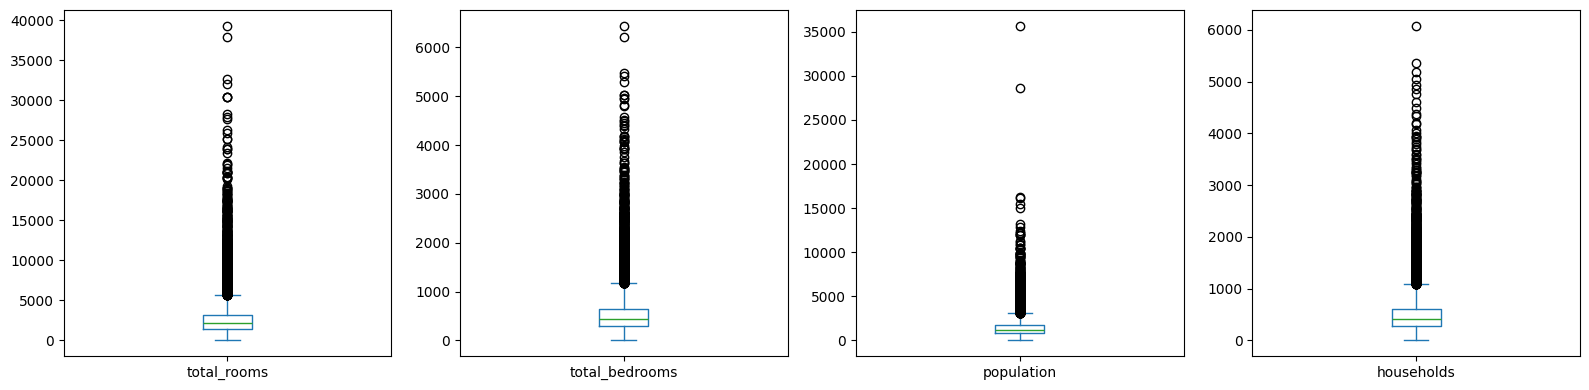

In [45]:
plt.figure(figsize=(10, 4))
final_df.plot(kind="box", subplots=True, layout=(1, 4), figsize=(16, 4), sharey=False)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

###  Reducing outliers

In [47]:
# Instead of raw totals, I am creating ratios/averages that are more meaningful and less redundant

In [48]:
epsilon = 1e-6

In [ ]:
final_df["rooms_per_household"] = final_df["total_rooms"] / (final_df["households"] + epsilon)
final_df["bedrooms_per_room"] = final_df["total_bedrooms"] / (final_df["total_rooms"] + epsilon)
final_df["population_per_household"] = final_df["population"] / (final_df["households"] + epsilon)

In [51]:
final_df.head()

,total_rooms,total_bedrooms,population,households,rooms_per_household,bedrooms_per_room,population_per_household
0,880.0,129.0,322.0,126.0,6.984127,0.146591,2.555556
1,7099.0,1106.0,2401.0,1138.0,6.238137,0.155797,2.109842
2,1467.0,190.0,496.0,177.0,8.288136,0.129516,2.802260
3,1274.0,235.0,558.0,219.0,5.817352,0.184458,2.547945
4,1627.0,280.0,565.0,259.0,6.281853,0.172096,2.181467


In [52]:
final_df = final_df.drop(columns=["total_rooms", "total_bedrooms", "population", "households"])

In [53]:
final_df.head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


### Visualizing Outliers

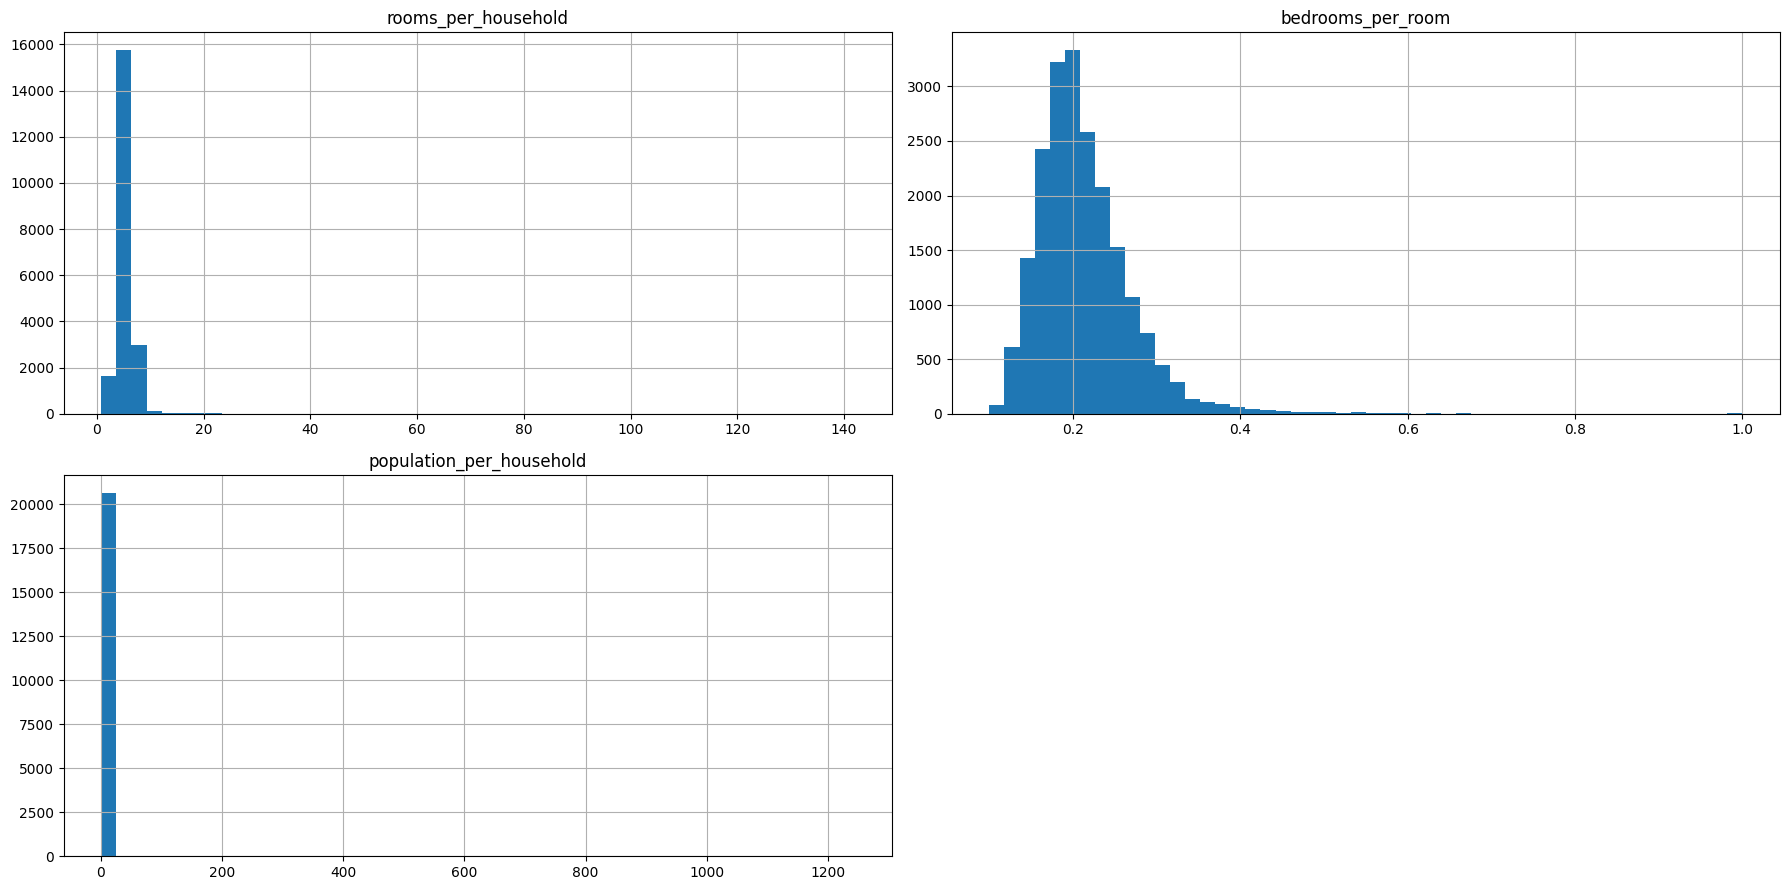

In [58]:
eng_cols = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]

final_df[eng_cols].hist(bins=50, figsize=(18, 9))
plt.tight_layout()
plt.show()

<Axes: xlabel='rooms_per_household', ylabel='Count'>

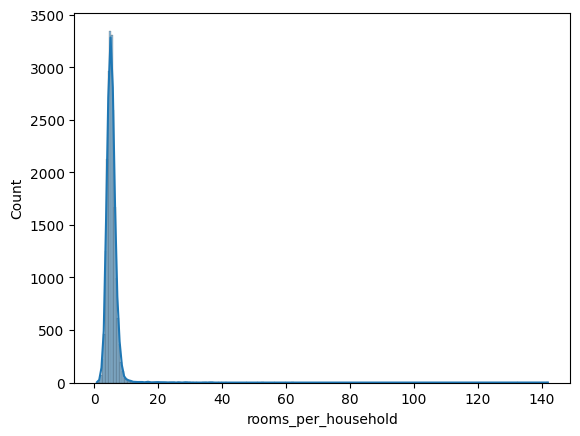

In [60]:
sns.histplot(final_df['rooms_per_household'], kde=True)

In [61]:
final_df.corr()

,rooms_per_household,bedrooms_per_room,population_per_household
rooms_per_household,1.000000,-0.416952,-0.004852
bedrooms_per_room,-0.416952,1.000000,0.002938
population_per_household,-0.004852,0.002938,1.000000


In [64]:
final_df.describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20433.000000,20640.000000
mean,5.429000,0.213039,3.070655
std,2.474173,0.057983,10.386048
min,0.846154,0.100000,0.692308
25%,4.440716,0.175427,2.429741
50%,5.229129,0.203162,2.818116
75%,6.052381,0.239821,3.282261
max,141.909078,1.000000,1243.333126


<Figure size 1000x400 with 0 Axes>

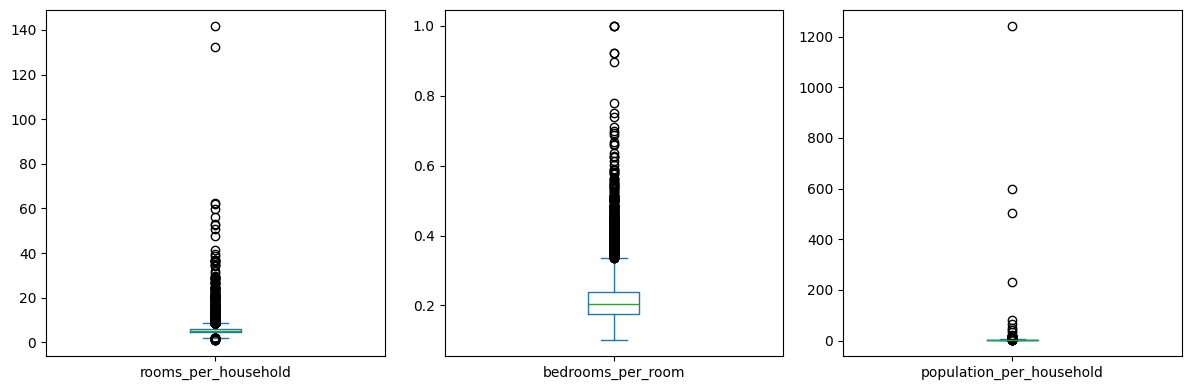

In [65]:
plt.figure(figsize=(10, 4))
final_df.plot(kind="box", subplots=True, layout=(1, 4), figsize=(16, 4), sharey=False)
plt.tight_layout()
plt.show()

### Handling Ouliers using IQR method

In [69]:
def handle_outliers(series, factor=1.5):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR= Q3 - Q1

    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    return series.clip (lower, upper)

In [70]:
for col in eng_cols:
    final_df[col]= handle_outliers( final_df[col], factor=1.5)

<Figure size 1000x400 with 0 Axes>

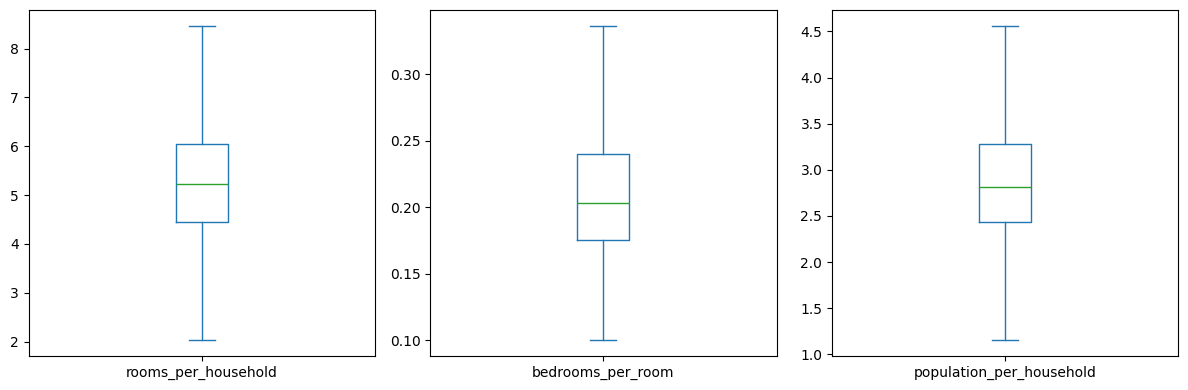

In [71]:
plt.figure(figsize=(10, 4))
final_df.plot(kind="box", subplots=True, layout=(1, 4), figsize=(16, 4), sharey=False)
plt.tight_layout()
plt.show()

In [72]:
#  Another method is we can apply..........>>>>> log transforms...........>>>> to reduce skew

# for col in eng_cols:
#     df[col + "_log"] = np.log1p(df[col])

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [136]:
X=final_df.copy()

In [137]:
X.head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


In [138]:
[f for f in X.columns if X[f].isnull().sum() > 0]

['bedrooms_per_room']

In [139]:
## Bedrooms_per room contains missing values
# handling Them

In [268]:
mean=X['bedrooms_per_room'].mean()
mean

np.float64(0.21089326171268713)

In [269]:
X['bedrooms_per_room']=X['bedrooms_per_room'].fillna(mean)

In [270]:
[f for f in X.columns if X[f].isnull().sum() > 0]

[]

In [265]:
scaler=StandardScaler()

In [266]:
X_scaled= scaler.fit_transform(X)

In [271]:
[f for f in final_df.columns if final_df[f].isnull().sum() > 0]

['bedrooms_per_room']

In [272]:
# f_df=final_df.copy()
# f_df.head()
# mean=final_df['bedrooms_per_room'].mean()
# print(mean)

# f_df['bedrooms_per_room']=f_df['bedrooms_per_room'].fillna(mean)
# f_df_scaled= StandardScaler().fit_transform(f_df)


0.21089326171268713


# Step 3: Choose a range of K (number of clusters)

In [144]:
from sklearn.cluster import KMeans

In [145]:
# K-Means requires you to specify k, so you rarely know the “true”  k upfront


### Manual Process
### Elbow Method to find optimal value for k

In [202]:
wcss=[]
for k in range(1,20):
    kmeans=KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    

In [203]:
wcss

[61919.999999999985,
 37649.00616384043,
 26349.212430041902,
 20457.99046443521,
 17191.065678078285,
 14795.96427889667,
 14661.558194297968,
 12121.646795229984,
 10973.397251955366,
 10180.733291165421,
 9201.292450301818,
 8594.196863980867,
 8227.091068678887,
 7609.595030899721,
 7210.248206141262,
 6836.049365314703,
 6599.190931204196,
 6229.425435845884,
 6014.219297124137]

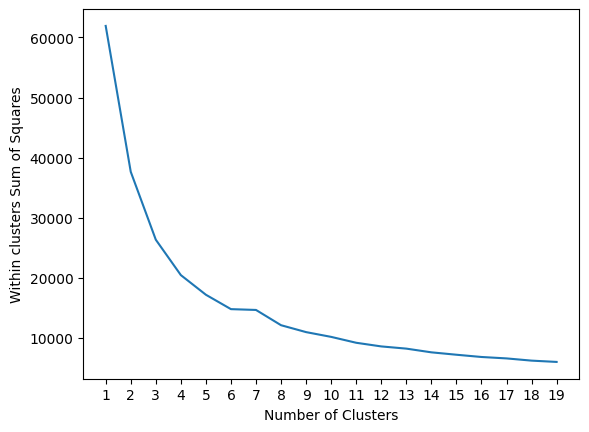

In [204]:
plt.plot( range(1,20), wcss)
plt.xticks(range(1,20))
plt.xlabel('Number of Clusters')
plt.ylabel('Within clusters Sum of Squares')
plt.show()

### Sochoosing K=3

In [185]:
## Manual process is good for small datasets but for large and to automate this process 
## we use a library------------->>>>> knee locator

In [308]:
from kneed import KneeLocator

In [326]:
kl=KneeLocator( range(1,20), wcss, curve='convex',direction='decreasing' )
print(kl.elbow)

5


### Silhouette method (more advanced)


In [207]:
from sklearn.metrics import silhouette_score

In [208]:
silhouette_coefficient=[]
for k in range (2,20):
    kmeans= KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)

    score=silhouette_score(X_scaled, kmeans.labels_)
    silhouette_coefficient.append(score)
    

In [209]:
silhoutte_coefficient

[0.3578832707204251,
 0.3735290792732858,
 0.3310790496063238,
 0.3262371735290943,
 0.3020942430463763,
 0.2885419903893863,
 0.2972081075815755,
 0.2825534291978114,
 0.2869389389450016,
 0.2975598536843792,
 0.2948670332593258,
 0.284505701679952,
 0.2823700929410032,
 0.2849159626477644,
 0.27500669450658677,
 0.28103719479501515,
 0.28570775848453583,
 0.27140069006841955]

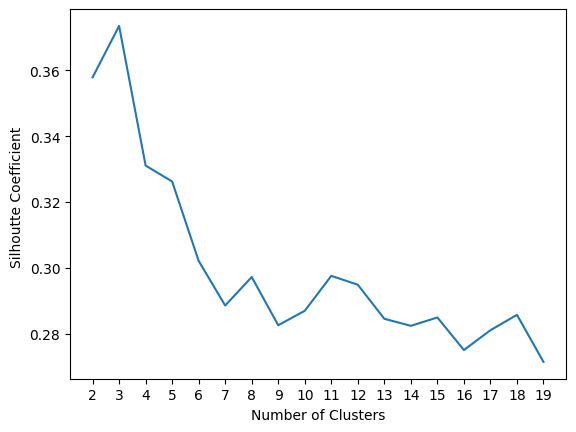

In [293]:
plt.plot( range(2,20), silhouette_coefficient)
plt.xticks(range(2,20))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhoutte Coefficient ')
plt.show()

In [188]:
### So k ======3

# Step 4: Running K-Means correctly 

In [301]:
kmeans=KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)


In [302]:
y_label=kmeans.fit_predict(X_scaled)

In [303]:
y_label

array([1, 1, 1, ..., 0, 0, 0], shape=(20640,), dtype=int32)

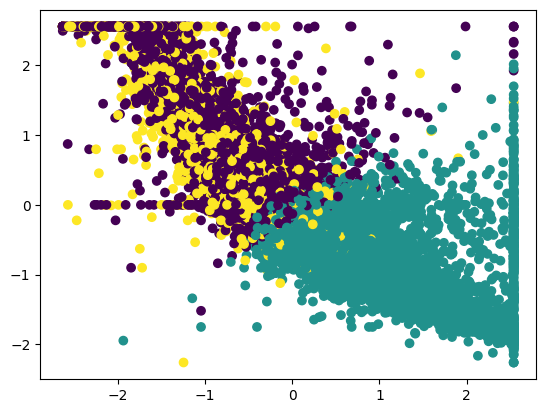

In [304]:
plt.scatter( X_scaled[:,0], X_scaled[:, 1], c=y_label)

In [ ]:
# The colored groups are your K-Means label
# The overlap means the clusters are not cleanly separable using only those 2 features

In [198]:
# My  data has many features, the clusters are formed using all of them,
# but the plot shows only two. So the projection can hide the real separation

# The cluster structure may exist across combinations of features, not just feature 0 and feature 1.

### Using PCA to reduce to 2D 

In [305]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [306]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


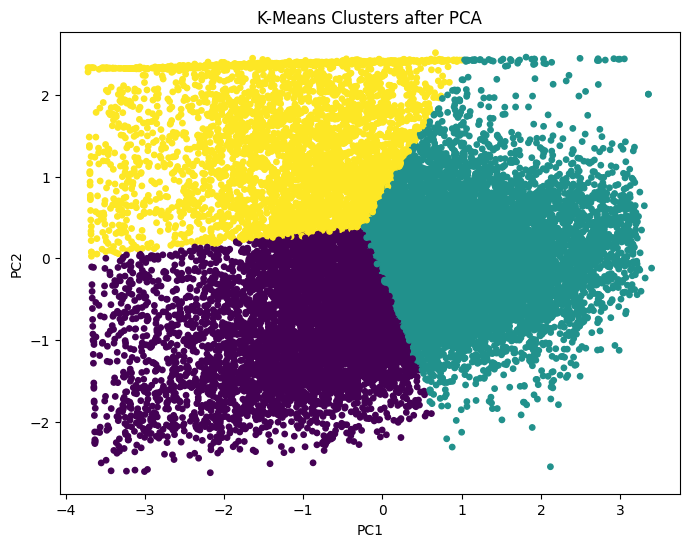

In [307]:

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_label, cmap="viridis", s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters after PCA")
plt.show()

# Step 5: Evaluating and interpreting clusters

## 1. Attach cluster labels back to your DataFrame

In [310]:
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [311]:
df['clusters']=kmeans.labels_

In [223]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,clusters
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0


## 2. Cluster profiling

In [224]:
# summarize each cluster

In [225]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [226]:
numeric_cols

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [312]:
cluster_profile= df.groupby('clusters')[numeric_cols].agg(['mean', 'median', 'min', 'max', 'count'])

In [313]:
print(cluster_profile)

           longitude                                  latitude                \
                mean  median     min     max  count       mean median    min   
clusters                                                                       
0        -118.877855 -118.25 -124.15 -114.57   3990  34.833852  34.06  32.54   
1        -119.736289 -119.32 -124.35 -114.31  10095  35.896507  35.35  32.56   
2        -119.734282 -118.52 -124.27 -114.55   6555  35.710040  34.26  32.57   

                        ... median_income                                  \
            max  count  ...          mean  median     min      max  count   
clusters                ...                                                 
0         41.81   3990  ...      2.646880  2.5204  0.4999  10.2264   3990   
1         41.95  10095  ...      4.904774  4.6000  0.4999  15.0001  10095   
2         41.95   6555  ...      3.023022  2.9693  0.4999  12.5000   6555   

         median_house_value                             

In [ ]:
## Express stats in a cleaner table for a few key features

In [314]:
key_features = ["median_income", "median_house_value", "housing_median_age"]

cluster_summary = df.groupby("clusters")[key_features].mean().round(2)
print(cluster_summary)

          median_income  median_house_value  housing_median_age
clusters                                                       
0                  2.65           140361.45               32.16
1                  4.90           234203.14               26.35
2                  3.02           205214.51               30.03


## 3. Visualization in original feature space (2D)

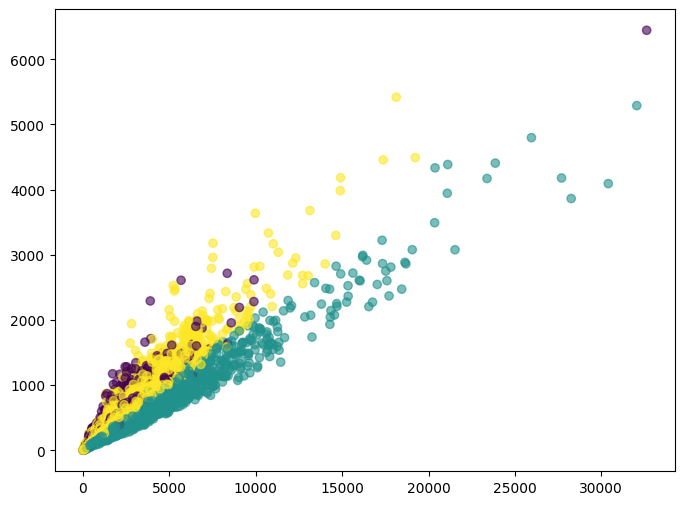

In [315]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["total_rooms"].head(10000),
    df["total_bedrooms"].head(10000),
    c=df["clusters"].head(10000),
    cmap="viridis",
    alpha=0.6
)

In [316]:
centroids = kmeans.cluster_centers_ 
centroids

array([[-0.82307792,  0.79359721,  1.41457639],
       [ 0.77003242, -0.76028647, -0.02558294],
       [-0.68198003,  0.68493403, -0.82041224]])

### Scaled final df

In [274]:
X_scaled_df = pd.DataFrame(X_scaled, columns=['rooms_per_household','bedrooms_per_room','population_per_household'])

In [275]:
X_scaled_df.head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,1.347665,-1.310930,-0.497871
1,0.749027,-1.123254,-1.142781
2,2.394098,-1.659035,-0.140910
3,0.411358,-0.538927,-0.508882
4,0.784108,-0.790961,-1.039145


In [276]:
rph_idx= list (X_scaled_df.columns).index('rooms_per_household')
bph_idx= list (X_scaled_df.columns).index('bedrooms_per_room')

In [317]:
# centroid coordinates in scaled space
centroids_scaled= centroids[:, [rph_idx, bph_idx]]
centroids_scaled

array([[-0.82307792,  0.79359721],
       [ 0.77003242, -0.76028647],
       [-0.68198003,  0.68493403]])

In [278]:
# To plot centroids on original scale, inverse-transform those two features:

 # I used scaler = StandardScaler() before 

In [318]:
centroids_original= scaler.inverse_transform(centroids)

In [319]:
X_scaled_df['clusters']=kmeans.labels_

In [322]:
X_scaled_df.head()

,rooms_per_household,bedrooms_per_room,population_per_household,clusters
0,1.347665,-1.310930,-0.497871,1
1,0.749027,-1.123254,-1.142781,1
2,2.394098,-1.659035,-0.140910,1
3,0.411358,-0.538927,-0.508882,1
4,0.784108,-0.790961,-1.039145,1


In [321]:
centroids_rph = centroids_original[:, rph_idx]
centroids_bph = centroids_original[:, bph_idx]

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_14052\3563917798.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="clusters")


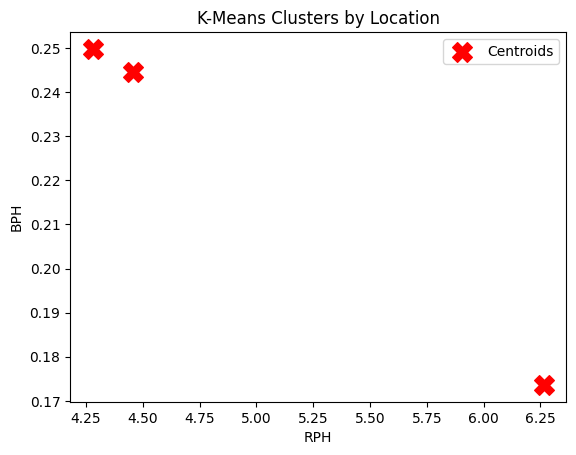

In [323]:
plt.scatter(
    centroids_rph,
    centroids_bph,
    c="red",
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("RPH")
plt.ylabel("BPH")
plt.title("K-Means Clusters by Location")
plt.legend()
plt.colorbar(scatter, label="clusters")
plt.show()

In [290]:
### Adding centroids as red Xs helps you see cluster centers

In [294]:
from sklearn.metrics import silhouette_score
import numpy as np

range_k = range(2, 11)
sil_scores = []

for k in range_k:
    kmeans_k = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans_k.fit(X_scaled)
    labels_k = kmeans_k.labels_
    sil = silhouette_score(X_scaled, labels_k)
    sil_scores.append(sil)

for k, sil in zip(range_k, sil_scores):
    print(f"k={k}, silhouette={sil:.3f}")

k=2, silhouette=0.358
k=3, silhouette=0.374
k=4, silhouette=0.331
k=5, silhouette=0.326
k=6, silhouette=0.303
k=7, silhouette=0.308
k=8, silhouette=0.296
k=9, silhouette=0.289
k=10, silhouette=0.300


# Step 6: Typical K-Means pitfalls to avoid

In [ ]:
# Using K-Means directly on unscaled features 
# (e.g., income in rupees vs age in years) so one feature dominates

In [295]:
# Applying it to heavily categorical data without careful encoding,
# where Euclidean distance does not make sense

In [296]:
# Expecting K-Means to find non-spherical or strongly unbalanced clusters; 
# density-based methods like DBSCAN or hierarchical clustering may be better there.
